# RNN Basics — Recurrent Neural Networks

## Goal
Understand how RNNs process sequential data.
CNNs see the whole input at once — RNNs process it step by step.

## Key Questions
- How does a network maintain memory across time steps?
- What is the vanishing gradient problem in sequences?
- Why did LSTMs replace vanilla RNNs?

## What We Build
A vanilla RNN from scratch, then compare with PyTorch's LSTM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## 1. How RNN Works
At each time step, RNN takes:
- Current input x_t
- Previous hidden state h_{t-1}

And produces:
- New hidden state h_t = tanh(W_x * x_t + W_h * h_{t-1} + b)

The hidden state is the "memory" of the network.

In [3]:
class VanillaRNN:
    def __init__(self, input_size: int, hidden_size: int):
        self.hidden_size = hidden_size
        np.random.seed(42)
        self.W_x = np.random.randn(hidden_size, input_size) * 0.1
        self.W_h = np.random.randn(hidden_size, hidden_size) * 0.1
        self.b = np.zeros((hidden_size, 1))

    def step(self, x_t: np.ndarray, h_prev: np.ndarray) -> np.ndarray:
        x_t = x_t.reshape(self.W_x.shape[1], 1)
        h_t = np.tanh(
            self.W_x @ x_t +
            self.W_h @ h_prev +
            self.b
        )
        return h_t

    def forward(self, sequence: np.ndarray) -> list:
        h = np.zeros((self.hidden_size, 1))
        hidden_states = []
        for x_t in sequence:
            h = self.step(x_t, h)
            hidden_states.append(h.copy())
        return hidden_states

rnn = VanillaRNN(input_size=3, hidden_size=4)
sequence = np.random.randn(5, 3)
hidden_states = rnn.forward(sequence)

print(f"Input: {len(sequence)} steps, {sequence.shape[1]} features")
print(f"Hidden size: {rnn.hidden_size}")
print(f"\nHidden state at each step:")
for i, h in enumerate(hidden_states):
    print(f"  Step {i+1}: {h.flatten().round(4)}")

Input: 5 steps, 3 features
Hidden size: 4

Hidden state at each step:
  Step 1: [-0.0647 -0.0704 -0.0888  0.009 ]
  Step 2: [0.0504 0.308  0.3198 0.1622]
  Step 3: [-0.0507  0.1013  0.0059  0.0614]
  Step 4: [-0.091  -0.2663 -0.4129 -0.0484]
  Step 5: [0.1484 0.1551 0.1312 0.085 ]


## 2. Visualize Hidden State Evolution
How does the hidden state change as the RNN processes the sequence?

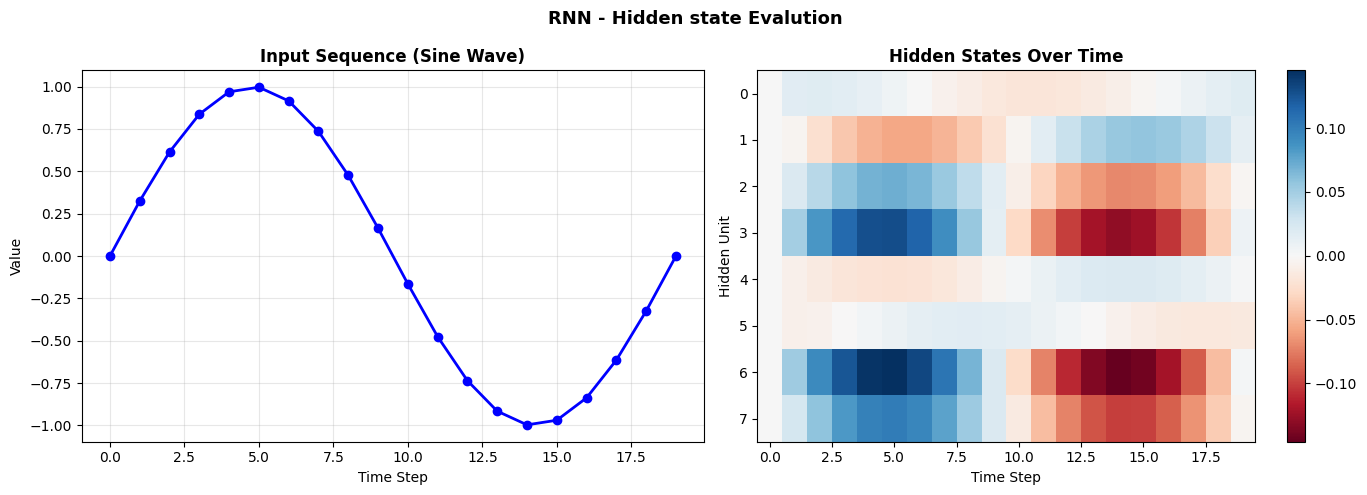

Hidden state matrix shape: (20, 8)
Each row = one time step, each column = one hidden unit


In [5]:
# Create a meaningful sequence - sine wave
t = np.linspace(0 ,2*np.pi, 20)
sequence = np.sin(t).reshape(-1, 1)

rnn = VanillaRNN(input_size=1, hidden_size=8)
hidden_states = rnn.forward(sequence)
hidden_matrix = np.array([h.flatten() for h in hidden_states])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Input sesequence
axes[0].plot(sequence, "b-o", linewidth=2, markersize=6)
axes[0].set_title("Input Sequence (Sine Wave)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3)

# Chart 2 - Hidden states heatmap
im = axes[1].imshow(hidden_matrix.T, cmap="RdBu", aspect="auto", interpolation="nearest")
axes[1].set_title("Hidden States Over Time", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Hidden Unit")
plt.colorbar(im, ax=axes[1])

plt.suptitle("RNN - Hidden state Evalution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rnn_hidden_state.png", dpi=300)
plt.show()

print(f"Hidden state matrix shape: {hidden_matrix.shape}")
print("Each row = one time step, each column = one hidden unit")

## 3. Vanishing Gradient in RNNs
RNNs struggle with long sequences — gradients vanish over time steps.

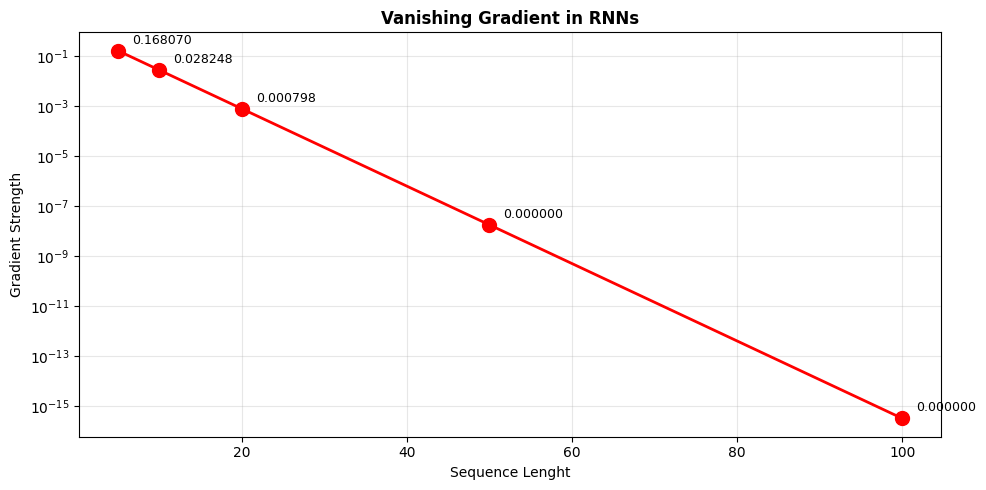

Gradient strenght at different sequence lengths:
 Length   5: 0.16807000
 Length  10: 0.02824752
 Length  20: 0.00079792
 Length  50: 0.00000002
 Length 100: 0.00000000


In [8]:
# Show how gradient weaknes over long sequences
sequence_lengths = [5, 10, 20, 50, 100]
gradient_strengths= []

for length in sequence_lengths:
    # Simulate gradient flow through time steps
    # Each step multplies by tanh derivative (max ~1, typically 0.5-0.7)
    tanh_derivative = 0.7 # typical value
    gradient = tanh_derivative ** length
    gradient_strengths.append(gradient)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sequence_lengths, gradient_strengths, "r-o", linewidth=2, markersize=10)
ax.set_title("Vanishing Gradient in RNNs", fontsize=12, fontweight="bold")
ax.set_xlabel("Sequence Lenght")
ax.set_ylabel("Gradient Strength")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

for length, strength in zip(sequence_lengths, gradient_strengths):
    ax.annotate(f"{strength:.6f}", (length, strength),
               textcoords="offset points", xytext=(10, 5), fontsize=9)

plt.tight_layout()
plt.savefig("rnn_vanishing_gradient.png", dpi=300)
plt.show()

print("Gradient strenght at different sequence lengths:")
for length, strength in zip(sequence_lengths, gradient_strengths):
    print(f" Length {length:3d}: {strength:.8f}")

## 4. Key Observations

| Sequence Length | Gradient Strength | Can Learn? |
|----------------|-------------------|------------|
| 5 | 0.168 | Yes |
| 10 | 0.028 | Barely |
| 20 | 0.0008 | No |
| 50 | ~0 | No |
| 100 | 0 | No |

## Why RNNs Fail on Long Sequences
Each time step multiplies the gradient by the tanh derivative (~0.7).
After 20 steps: gradient ≈ 0.0008 — early tokens contribute almost nothing.
The network forgets what it saw at the beginning of the sequence.

## Solution: LSTM
Long Short-Term Memory (LSTM) adds gates that control information flow:
- Forget gate: what to discard from memory
- Input gate: what new information to store
- Output gate: what to output

Gates use sigmoid (0-1) — they can keep gradients alive over long sequences.

## Connection to Transformers
Transformers solved this differently — with attention.
Instead of passing hidden state step by step,
attention looks at ALL positions simultaneously.
No sequential bottleneck. No vanishing gradient across time.
This is why transformers replaced RNNs for NLP.

## Next
How does attention work?
-> 06_transformer_basics.ipynb